# Experiment 3.1 — Raw vs SNN Representation Value

Analysis-only notebook for the finalized matched comparison. Run the Slurm pipeline first; this notebook does not train or evaluate the SNN.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

def find_repo_root(start=Path.cwd()):
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'snn').is_dir() and (candidate / 'notebooks').is_dir():
            return candidate
    raise FileNotFoundError('Could not locate repository root')

REPO_ROOT = find_repo_root()
RESULTS = REPO_ROOT / 'notebooks' / 'artifacts' / 'experiment_3_1_raw_vs_snn_representation_value' / 'matched_repr_v1'
RESULTS

PosixPath('/home/zhaolongwei_umass_edu/projects/writingRing/notebooks/artifacts/experiment_3_1_raw_vs_snn_representation_value/matched_repr_v1')

In [2]:
primary = pd.read_csv(RESULTS / 'experiment_3_1_primary_comparison.csv')
summary = pd.read_csv(RESULTS / 'experiment_3_1_probe_summary.csv')
deltas = pd.read_csv(RESULTS / 'experiment_3_1_paired_deltas.csv')
delta_summary = pd.read_csv(RESULTS / 'experiment_3_1_delta_summary.csv')
with (RESULTS / 'experiment_3_1_conclusion.json').open('r', encoding='utf-8') as handle:
    conclusion = json.load(handle)
primary

,probe_type,raw_mean_test_ba,fusion_mean_test_ba,snn_mean_test_ba,mean_snn_minus_raw_test_ba,sd_snn_minus_raw_test_ba,mean_fusion_minus_raw_test_ba,sd_fusion_minus_raw_test_ba,mean_fusion_minus_snn_test_ba,sd_fusion_minus_snn_test_ba
0,fixed250_ordered,0.548475,0.631865,0.625945,0.077470,0.023422,0.083390,0.029887,0.005920,0.031401
1,fixed250_pca128,0.500984,0.564782,0.585872,0.084887,0.020957,0.063798,0.013385,-0.021090,0.028084
2,relative10_ordered,0.739481,0.726725,0.682000,-0.057481,0.035447,-0.012756,0.026786,0.044725,0.038810
3,relative10_pca128,0.719403,0.693469,0.660617,-0.058786,0.033782,-0.025933,0.010214,0.032852,0.034255


## Primary matched comparison

The primary endpoints are ordered and PCA128 Fixed250/Relative10 probes. Positive `SNN - Raw` indicates the frozen SNN itself improves linear separability; positive `Fusion - Raw` indicates complementary information.

In [3]:
display(primary)
display(delta_summary[delta_summary['probe_type'].isin(['fixed250_ordered', 'fixed250_pca128', 'relative10_ordered', 'relative10_pca128'])])

,probe_type,raw_mean_test_ba,fusion_mean_test_ba,snn_mean_test_ba,mean_snn_minus_raw_test_ba,sd_snn_minus_raw_test_ba,mean_fusion_minus_raw_test_ba,sd_fusion_minus_raw_test_ba,mean_fusion_minus_snn_test_ba,sd_fusion_minus_snn_test_ba
0,fixed250_ordered,0.548475,0.631865,0.625945,0.077470,0.023422,0.083390,0.029887,0.005920,0.031401
1,fixed250_pca128,0.500984,0.564782,0.585872,0.084887,0.020957,0.063798,0.013385,-0.021090,0.028084
2,relative10_ordered,0.739481,0.726725,0.682000,-0.057481,0.035447,-0.012756,0.026786,0.044725,0.038810
3,relative10_pca128,0.719403,0.693469,0.660617,-0.058786,0.033782,-0.025933,0.010214,0.032852,0.034255


,probe_type,n_runs,mean_snn_minus_raw_test_ba,sd_snn_minus_raw_test_ba,mean_fusion_minus_raw_test_ba,sd_fusion_minus_raw_test_ba,mean_fusion_minus_snn_test_ba,sd_fusion_minus_snn_test_ba,mean_snn_minus_raw_val_ba,sd_snn_minus_raw_val_ba,mean_fusion_minus_raw_val_ba,sd_fusion_minus_raw_val_ba
0,fixed250_ordered,3,0.077470,0.023422,0.083390,0.029887,0.005920,0.031401,-0.015859,0.039262,-0.000928,0.034394
1,fixed250_pca128,3,0.084887,0.020957,0.063798,0.013385,-0.021090,0.028084,-0.059606,0.032246,-0.047174,0.025111
4,relative10_ordered,3,-0.057481,0.035447,-0.012756,0.026786,0.044725,0.038810,0.011971,0.014148,0.049022,0.008719
5,relative10_pca128,3,-0.058786,0.033782,-0.025933,0.010214,0.032852,0.034255,-0.011334,0.006706,0.037863,0.015151


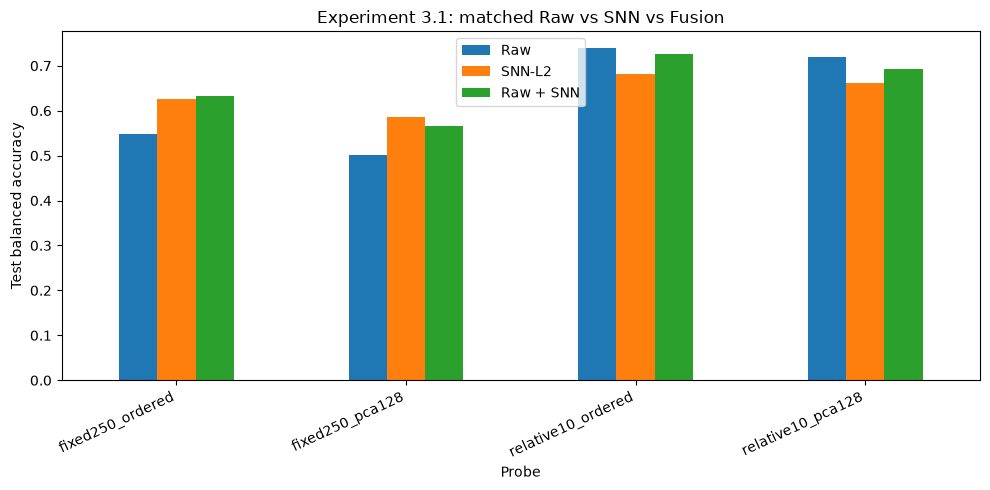

In [4]:
plot_df = primary.set_index('probe_type')[['raw_mean_test_ba', 'snn_mean_test_ba', 'fusion_mean_test_ba']]
ax = plot_df.plot(kind='bar', figsize=(10, 5))
ax.set_ylabel('Test balanced accuracy')
ax.set_xlabel('Probe')
ax.set_title('Experiment 3.1: matched Raw vs SNN vs Fusion')
ax.legend(['Raw', 'SNN-L2', 'Raw + SNN'])
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

## Per-seed paired deltas

In [5]:
display(deltas[deltas['probe_type'].isin(['fixed250_ordered', 'fixed250_pca128', 'relative10_ordered', 'relative10_pca128'])].sort_values(['probe_type', 'seed']))

,seed,probe_type,raw_test_ba,snn_test_ba,fusion_test_ba,snn_minus_raw_test_ba,fusion_minus_raw_test_ba,fusion_minus_snn_test_ba,snn_minus_raw_val_ba,fusion_minus_raw_val_ba
1,11,fixed250_ordered,0.548475,0.642111,0.664741,0.093636,0.116266,0.022630,0.000752,0.013294
8,23,fixed250_ordered,0.548475,0.599084,0.624517,0.050609,0.076042,0.025433,0.012368,0.024074
15,101,fixed250_ordered,0.548475,0.636640,0.606337,0.088165,0.057862,-0.030303,-0.060696,-0.040152
3,11,fixed250_pca128,0.500984,0.598859,0.574689,0.097874,0.073704,-0.024170,-0.022433,-0.033039
10,23,fixed250_pca128,0.500984,0.597062,0.549555,0.096078,0.048571,-0.047507,-0.076341,-0.032317
17,101,fixed250_pca128,0.500984,0.561695,0.570103,0.060710,0.069118,0.008408,-0.080044,-0.076166
4,11,relative10_ordered,0.739481,0.715334,0.750327,-0.024147,0.010845,0.034993,0.024567,0.053740
11,23,relative10_ordered,0.739481,0.644762,0.732237,-0.094719,-0.007244,0.087475,-0.003337,0.054365
18,101,relative10_ordered,0.739481,0.685904,0.697612,-0.053578,-0.041869,0.011708,0.014683,0.038961
6,11,relative10_pca128,0.719403,0.676772,0.704656,-0.042631,-0.014747,0.027884,-0.014220,0.024206


## Temporal-order controls

In [6]:
order_controls = summary[summary['probe_type'].isin(['fixed250_ordered', 'fixed250_shuffled', 'relative10_ordered', 'relative10_shuffled'])]
display(order_controls.sort_values(['representation', 'probe_type']))

,representation,probe_type,n_runs,mean_probe_val_balanced_accuracy,sd_probe_val_balanced_accuracy,mean_probe_test_balanced_accuracy,sd_probe_test_balanced_accuracy,mean_probe_test_macro_f1,sd_probe_test_macro_f1,mean_probe_test_accuracy,sd_probe_test_accuracy
1,raw,fixed250_ordered,1,0.587290,0.000000,0.548475,0.000000,0.537217,0.000000,0.554795,0.000000
3,raw,fixed250_shuffled,1,0.276665,0.000000,0.250939,0.000000,0.238074,0.000000,0.253425,0.000000
5,raw,relative10_ordered,1,0.622739,0.000000,0.739481,0.000000,0.745279,0.000000,0.760274,0.000000
7,raw,relative10_shuffled,1,0.268795,0.000000,0.173095,0.000000,0.161269,0.000000,0.178082,0.000000
8,raw_plus_snn,fixed250_ordered,3,0.586362,0.034394,0.631865,0.029887,0.634180,0.029907,0.648402,0.027681
10,raw_plus_snn,fixed250_shuffled,3,0.509600,0.034200,0.458661,0.017366,0.465799,0.017317,0.474886,0.017237
12,raw_plus_snn,relative10_ordered,3,0.671761,0.008719,0.726725,0.026786,0.728430,0.024132,0.746575,0.031388
14,raw_plus_snn,relative10_shuffled,3,0.502060,0.002564,0.545666,0.030494,0.542083,0.032422,0.563927,0.030885
15,snn_l2,fixed250_ordered,3,0.571431,0.039262,0.625945,0.023422,0.625302,0.023248,0.641553,0.022017
17,snn_l2,fixed250_shuffled,3,0.490336,0.009635,0.481092,0.039459,0.485538,0.035807,0.497717,0.038947


In [7]:
conclusion

{'experiment_id': 'experiment_3_1_raw_vs_snn_representation_value',
 'fixed250_ordered': {'fusion_mean_test_ba': 0.6318651256151254,
  'mean_fusion_minus_raw_test_ba': 0.08338998963998952,
  'mean_fusion_minus_snn_test_ba': 0.005920005920005855,
  'mean_snn_minus_raw_test_ba': 0.07746998371998366,
  'probe_type': 'fixed250_ordered',
  'raw_mean_test_ba': 0.548475135975136,
  'sd_fusion_minus_raw_test_ba': 0.02988701909400341,
  'sd_fusion_minus_snn_test_ba': 0.03140135539638188,
  'sd_snn_minus_raw_test_ba': 0.023422438296115324,
  'snn_mean_test_ba': 0.6259451196951197},
 'fixed250_pca128': {'fusion_mean_test_ba': 0.5647822085322085,
  'mean_fusion_minus_raw_test_ba': 0.06379777629777628,
  'mean_fusion_minus_snn_test_ba': -0.02108955858955856,
  'mean_snn_minus_raw_test_ba': 0.08488733488733484,
  'probe_type': 'fixed250_pca128',
  'raw_mean_test_ba': 0.5009844322344322,
  'sd_fusion_minus_raw_test_ba': 0.013384732644588521,
  'sd_fusion_minus_snn_test_ba': 0.0280844731427117,
  'sd_